In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
pd.set_option('display.max_columns', None)

In [122]:
df = pd.read_csv('cleaned_anime.csv')
df.head()

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,english_title,show_type,status,aired,broadcast,producers,licensors,source,genres,duration_min,episodes,rating,themes,demographics,favorites,broadcast_day,broadcast_time
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,madhouse,during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,frieren: beyond journey's end,tv,finished airing,"sep 29, 2023 to mar 22, 2024",fridays at 23:00 (jst),"aniplex, dentsu, shogakukan-shueis...",crunchyroll,manga,"adventure, award winning, drama, fantasy",24.0,28.0,pg-13 - teens 13 or older,NaN,shounen,88070,Friday,23:00:00
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,NaN,david production,"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,steel ball run: jojo's bizarre adventure,ona,currently airing,"mar 19, 2026 to ?",NaN,"warner bros. japan, studio mausu, ...",NaN,manga,"action, adventure, mystery, supernatural",47.0,NaN,r - 17+ (violence & profanity),"historical, racing","seinen, shounen",6051,NaN,NaN
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,bones,after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,fullmetal alchemist: brotherhood,tv,finished airing,"apr 5, 2009 to jul 4, 2010",sundays at 17:00 (jst),"aniplex, square enix, mainichi bro...","funimation, aniplex of america",manga,"action, adventure, drama, fantasy",24.0,64.0,r - 17+ (violence & profanity),military,shounen,241796,Sunday,17:00:00
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,NaN,mappa,despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,chainsaw man – the movie: reze arc,movie,finished airing,"sep 19, 2025",NaN,NaN,NaN,manga,"action, fantasy",99.0,1.0,r - 17+ (violence & profanity),"gore, urban fantasy",shounen,12951,NaN,NaN
4,steins;gate,9.07,1516022,14,2802086,spring 2011,white fox,eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,steins;gate,tv,finished airing,"apr 6, 2011 to sep 14, 2011",wednesdays at 02:05 (jst),"frontier works, media factory, kad...",funimation,visual novel,"drama, sci-fi, suspense",24.0,24.0,pg-13 - teens 13 or older,"psychological, time travel",NaN,201780,Wednesday,02:05:00


In [123]:
df1 = df.copy()

In [124]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10142 entries, 0 to 10141
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            10142 non-null  object 
 1   score            10142 non-null  float64
 2   people_scored    10142 non-null  int64  
 3   popularity       10142 non-null  int64  
 4   members          10142 non-null  int64  
 5   season           4427 non-null   object 
 6   studio           9717 non-null   object 
 7   description      10141 non-null  object 
 8   recommended      10142 non-null  int64  
 9   mixed_feelings   10142 non-null  int64  
 10  not_recommended  10142 non-null  int64  
 11  rec              8198 non-null   object 
 12  mix              6870 non-null   object 
 13  not_rec          6004 non-null   object 
 14  english_title    7041 non-null   object 
 15  show_type        10142 non-null  object 
 16  status           10142 non-null  object 
 17  aired       

In [125]:
df1.isnull().sum()

title                 0
score                 0
people_scored         0
popularity            0
members               0
season             5715
studio              425
description           1
recommended           0
mixed_feelings        0
not_recommended       0
rec                1944
mix                3272
not_rec            4138
english_title      3101
show_type             0
status                0
aired                 0
broadcast          6398
producers          2832
licensors          5967
source              418
genres              301
duration_min         44
episodes             69
rating               54
themes             2817
demographics       6366
favorites             0
broadcast_day      6440
broadcast_time     6467
dtype: int64

In [126]:
# 1) Normalize missing season values
df1["season"] = (
    df1["season"]
    .astype(str)
    .str.strip()
    .replace({"": np.nan, "nan": np.nan, "none": np.nan, "None": np.nan})
)

# 2) Parse start date from "aired" (example: "sep 29, 2023 to mar 22, 2024")
start_date_str = df1["aired"].str.extract(r"(?i)^([a-z]{3}\s+\d{1,2},\s+\d{4})")[0]
start_date = pd.to_datetime(start_date_str, format="%b %d, %Y", errors="coerce")

def month_to_season(m):
    if m in [12, 1, 2]:
        return "winter"
    if m in [3, 4, 5]:
        return "spring"
    if m in [6, 7, 8]:
        return "summer"
    return "fall"

inferred_season = start_date.apply(
    lambda d: f"{month_to_season(d.month)} {d.year}" if pd.notna(d) else np.nan
)

# 3) Fill only missing season from inferred values
df1["season"] = df1["season"].fillna(inferred_season)

# 4) Keep indicator + final fallback
df1["season"] = df1["season"].fillna("unknown")

print("Remaining missing season:", df1["season"].isna().sum())
print(df1["season"].value_counts(dropna=False).head(10))

Remaining missing season: 0
season
fall 2023      133
winter 2023    122
summer 2024    119
spring 2018    118
fall 2024      115
fall 2016      114
fall 2017      114
spring 2017    113
spring 2024    113
summer 2022    112
Name: count, dtype: int64


In [127]:
df1.isnull().sum()

title                 0
score                 0
people_scored         0
popularity            0
members               0
season                0
studio              425
description           1
recommended           0
mixed_feelings        0
not_recommended       0
rec                1944
mix                3272
not_rec            4138
english_title      3101
show_type             0
status                0
aired                 0
broadcast          6398
producers          2832
licensors          5967
source              418
genres              301
duration_min         44
episodes             69
rating               54
themes             2817
demographics       6366
favorites             0
broadcast_day      6440
broadcast_time     6467
dtype: int64

In [128]:
df1 = df1.drop(columns=['broadcast','broadcast_day', 'english_title', 'broadcast_time', 'themes', 'demographics', 'producers', 'licensors'])

In [129]:
df1['duration_min'] = df1['duration_min'].fillna(df1['duration_min'].mode().iloc[0])
df1['episodes'] = df1['episodes'].fillna(df1['episodes'].median())
df1['description'] = df1['description'].fillna('unknown')
df1['source'] = df1['source'].fillna('unknown')
df1['studio'] = df1['studio'].fillna('unknown')
df1['genres'] = df1['genres'].fillna('unknown')
df1['rating'] = df1['rating'].fillna('unknown')

In [130]:
df1.isnull().sum()

title                 0
score                 0
people_scored         0
popularity            0
members               0
season                0
studio                0
description           0
recommended           0
mixed_feelings        0
not_recommended       0
rec                1944
mix                3272
not_rec            4138
show_type             0
status                0
aired                 0
source                0
genres                0
duration_min          0
episodes              0
rating                0
favorites             0
dtype: int64

In [131]:
eps = 1e-6
# Create new features based on existing ones
df1['reviews'] = df1['mixed_feelings'] + df1['recommended'] + df1['not_recommended']
df1['favs_rate'] = (df1['favorites'] + eps) / (df1['members'] + eps)
df1['desc_length'] = df1['description'].str.len()
df1['scored_rate'] = (df1['people_scored'] + eps) / (df1['members'] + eps)
# Review shares: what fraction of reviews are positive, negative, or mixed
df1["rec_share"] = df1["recommended"] / (df1["reviews"] + eps)
df1["mix_share"] = df1["mixed_feelings"] / (df1["reviews"] + eps)
df1["not_rec_share"] = df1["not_recommended"] / (df1["reviews"] + eps)

# Sentiment balance means how much more positive than negative the reviews are, normalized by total reviews
df1["sentiment_balance"] = (df1["recommended"] - df1["not_recommended"]) / (df1["reviews"] + eps)

In [132]:
df1.head()

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,show_type,status,aired,source,genres,duration_min,episodes,rating,favorites,reviews,favs_rate,desc_length,scored_rate,rec_share,mix_share,not_rec_share,sentiment_balance
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,madhouse,during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,tv,finished airing,"sep 29, 2023 to mar 22, 2024",manga,"adventure, award winning, drama, fantasy",24.0,28.0,pg-13 - teens 13 or older,88070,1079,0.062400,1099,0.616229,0.759036,0.133457,0.107507,0.651529
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,spring 2026,david production,"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,ona,currently airing,"mar 19, 2026 to ?",manga,"action, adventure, mystery, supernatural",47.0,11.0,r - 17+ (violence & profanity),6051,164,0.031859,1194,0.454965,0.951220,0.042683,0.006098,0.945122
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,bones,after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,tv,finished airing,"apr 5, 2009 to jul 4, 2010",manga,"action, adventure, drama, fantasy",24.0,64.0,r - 17+ (violence & profanity),241796,1084,0.065924,1169,0.628020,0.895756,0.063653,0.040590,0.855166
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,fall 2025,mappa,despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,movie,finished airing,"sep 19, 2025",manga,"action, fantasy",99.0,1.0,r - 17+ (violence & profanity),12951,387,0.028830,865,0.628552,0.832041,0.118863,0.049096,0.782946
4,steins;gate,9.07,1516022,14,2802086,spring 2011,white fox,eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,tv,finished airing,"apr 6, 2011 to sep 14, 2011",visual novel,"drama, sci-fi, suspense",24.0,24.0,pg-13 - teens 13 or older,201780,1247,0.072011,1144,0.541033,0.862069,0.070569,0.067362,0.794707


In [133]:
df1.shape

(10142, 31)

(0.0, 300.0)

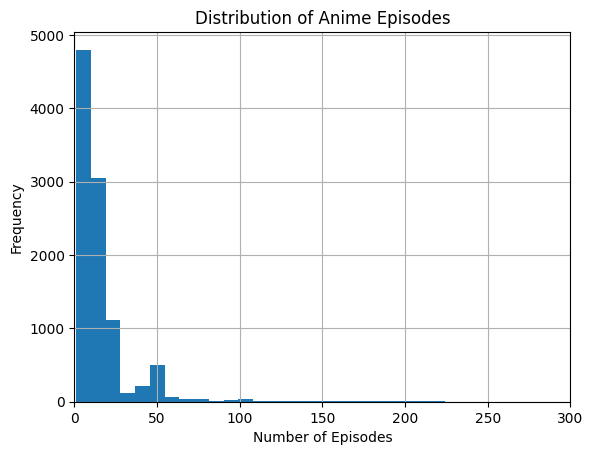

In [134]:
df1['episodes'].hist(bins= 200)
plt.title('Distribution of Anime Episodes')
plt.xlabel('Number of Episodes')
plt.ylabel('Frequency')
plt.xlim(0, 300)

Text(0, 0.5, 'Frequency')

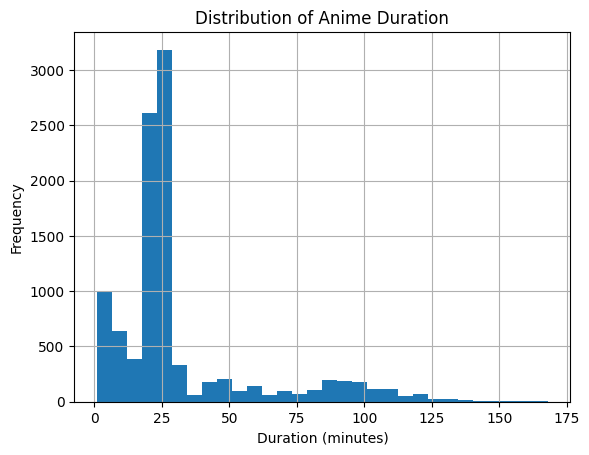

In [135]:
df1['duration_min'].hist(bins= 30)
plt.title('Distribution of Anime Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')

(0.0, 150.0)

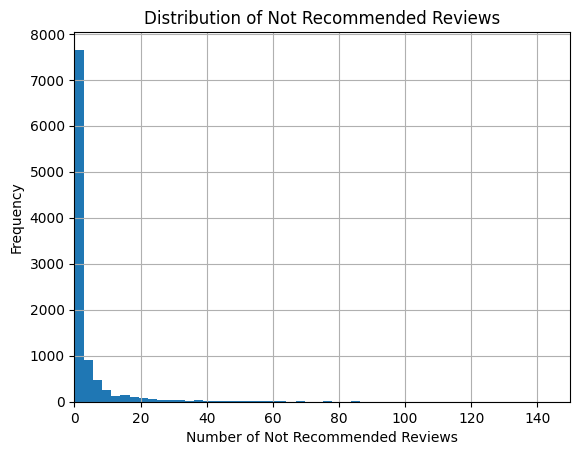

In [136]:
df1['not_recommended'].hist(bins= 150)
plt.title('Distribution of Not Recommended Reviews')
plt.xlabel('Number of Not Recommended Reviews')
plt.ylabel('Frequency')
plt.xlim(0, 150)

(0.0, 150.0)

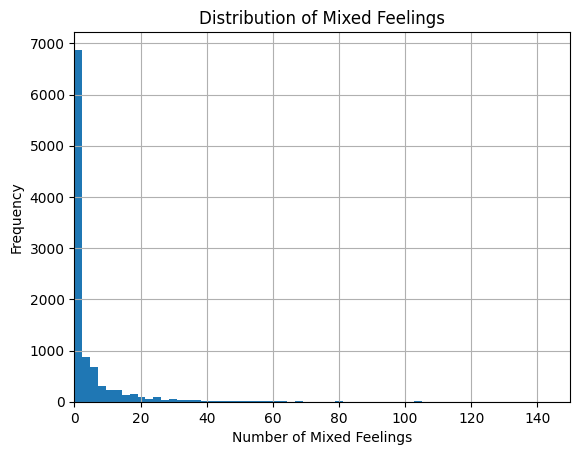

In [137]:
df1['mixed_feelings'].hist(bins= 150)
plt.title('Distribution of Mixed Feelings')
plt.xlabel('Number of Mixed Feelings')
plt.ylabel('Frequency')
plt.xlim(0, 150)

(0.0, 450.0)

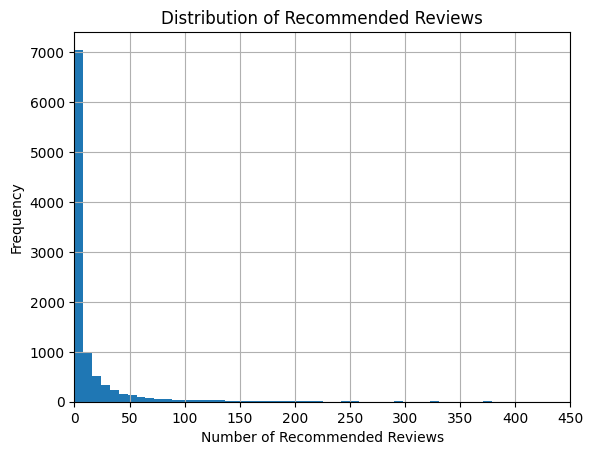

In [138]:
df1['recommended'].hist(bins= 150)
plt.title('Distribution of Recommended Reviews')
plt.xlabel('Number of Recommended Reviews')
plt.ylabel('Frequency')
plt.xlim(0, 450)

Text(0, 0.5, 'Frequency')

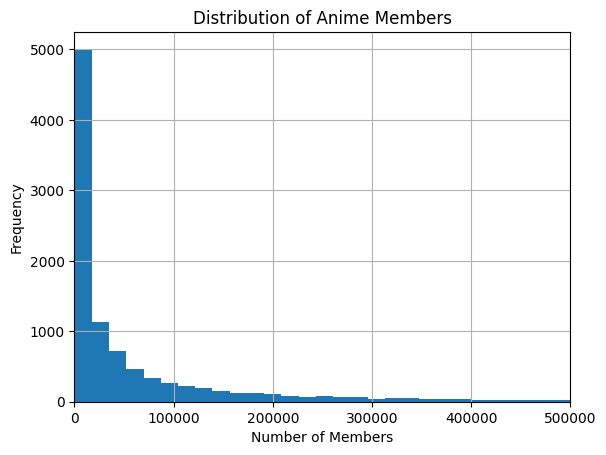

In [139]:
df1['members'].hist(bins= 250)
plt.title('Distribution of Anime Members')
plt.xlim(0, 500000)
plt.xlabel('Number of Members')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

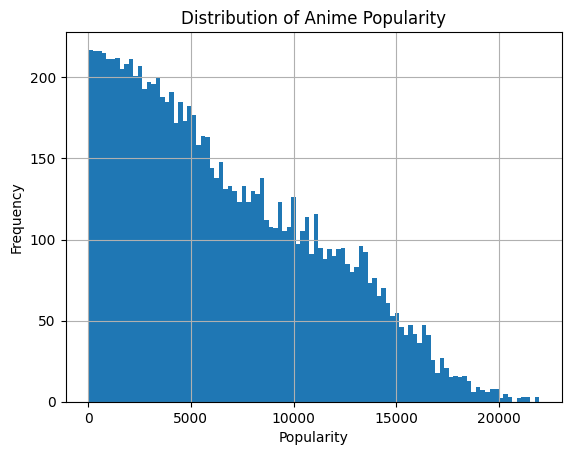

In [140]:
df1['popularity'].hist(bins= 100)
plt.title('Distribution of Anime Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')

(0.0, 500.0)

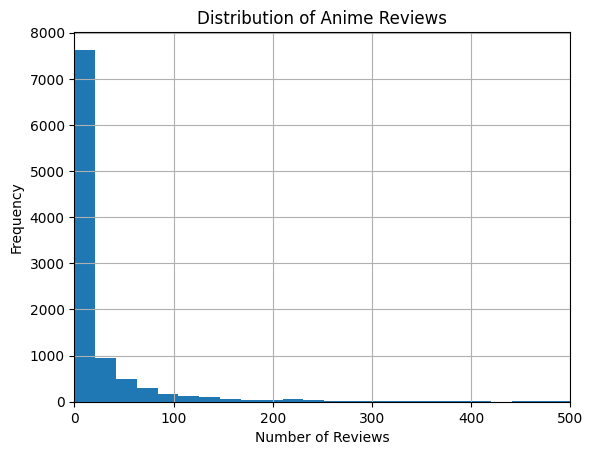

In [141]:
df1['reviews'].hist(bins= 75)
plt.title('Distribution of Anime Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.xlim(0, 500)

(0.0, 1500000.0)

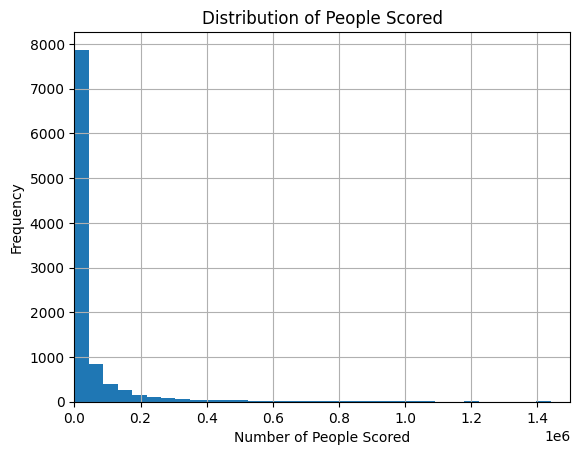

In [142]:
df1['people_scored'].hist(bins= 70)
plt.title('Distribution of People Scored')
plt.xlabel('Number of People Scored')
plt.ylabel('Frequency')
plt.xlim(0, 1500000)

Text(0, 0.5, 'Frequency')

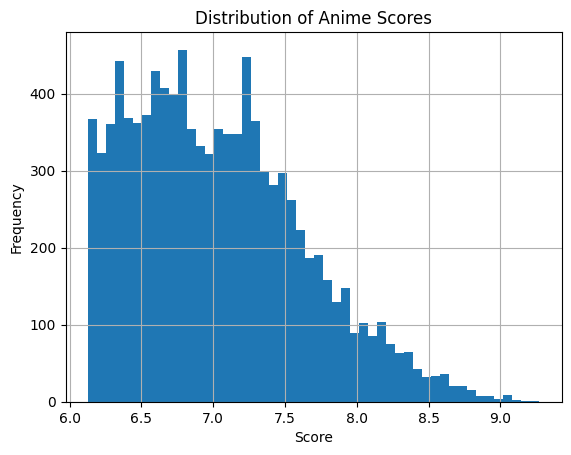

In [143]:
df1['score'].hist(bins= 50)
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')

In [144]:
df2 = df1.copy()
df2.head()

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,show_type,status,aired,source,genres,duration_min,episodes,rating,favorites,reviews,favs_rate,desc_length,scored_rate,rec_share,mix_share,not_rec_share,sentiment_balance
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,madhouse,during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,tv,finished airing,"sep 29, 2023 to mar 22, 2024",manga,"adventure, award winning, drama, fantasy",24.0,28.0,pg-13 - teens 13 or older,88070,1079,0.062400,1099,0.616229,0.759036,0.133457,0.107507,0.651529
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,spring 2026,david production,"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,ona,currently airing,"mar 19, 2026 to ?",manga,"action, adventure, mystery, supernatural",47.0,11.0,r - 17+ (violence & profanity),6051,164,0.031859,1194,0.454965,0.951220,0.042683,0.006098,0.945122
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,bones,after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,tv,finished airing,"apr 5, 2009 to jul 4, 2010",manga,"action, adventure, drama, fantasy",24.0,64.0,r - 17+ (violence & profanity),241796,1084,0.065924,1169,0.628020,0.895756,0.063653,0.040590,0.855166
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,fall 2025,mappa,despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,movie,finished airing,"sep 19, 2025",manga,"action, fantasy",99.0,1.0,r - 17+ (violence & profanity),12951,387,0.028830,865,0.628552,0.832041,0.118863,0.049096,0.782946
4,steins;gate,9.07,1516022,14,2802086,spring 2011,white fox,eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,tv,finished airing,"apr 6, 2011 to sep 14, 2011",visual novel,"drama, sci-fi, suspense",24.0,24.0,pg-13 - teens 13 or older,201780,1247,0.072011,1144,0.541033,0.862069,0.070569,0.067362,0.794707


In [145]:
df2['rec'] = df2['rec'].fillna('unknown')
df2['mix'] = df2['mix'].fillna('unknown')
df2['not_rec'] = df2['not_rec'].fillna('unknown')

In [146]:
df2.isnull().sum()

title                0
score                0
people_scored        0
popularity           0
members              0
season               0
studio               0
description          0
recommended          0
mixed_feelings       0
not_recommended      0
rec                  0
mix                  0
not_rec              0
show_type            0
status               0
aired                0
source               0
genres               0
duration_min         0
episodes             0
rating               0
favorites            0
reviews              0
favs_rate            0
desc_length          0
scored_rate          0
rec_share            0
mix_share            0
not_rec_share        0
sentiment_balance    0
dtype: int64

In [147]:
df1.to_csv('feature_engineered_anime.csv', index=False)
df2.to_csv('feature_engineered_anime_alt.csv', index=False)